### QAOA - Max-Cut Problem
 - Objective - Evaluate the performance of QAOA for solving the Max-Cut problem 
 - Circuit Used - Qiskit QAOA Ansatz
 - Nodes - 4 nodes
 - Edges - 5 edges

#### Step 1 - Create a simple graph

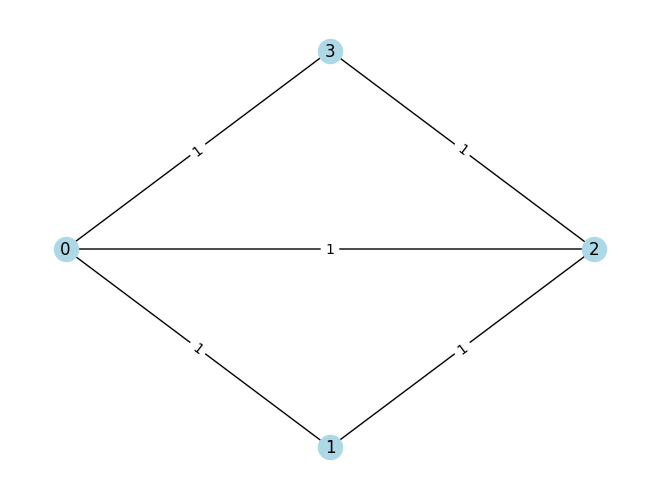

In [3]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw

nodes = 4
G = rx.PyGraph()
G.add_nodes_from(range(nodes))
edges = [(0, 1, 1), (0, 2, 1), (0, 3, 1),(1, 2, 1), (2, 3, 1)]
G.add_edges_from(edges)

mpl_draw(G, pos=rx.shell_layout(G),with_labels=True, edge_labels=str, node_color="lightblue")

#### Step 2 - Define the QAOA Ansatz and the cost Hamiltonian

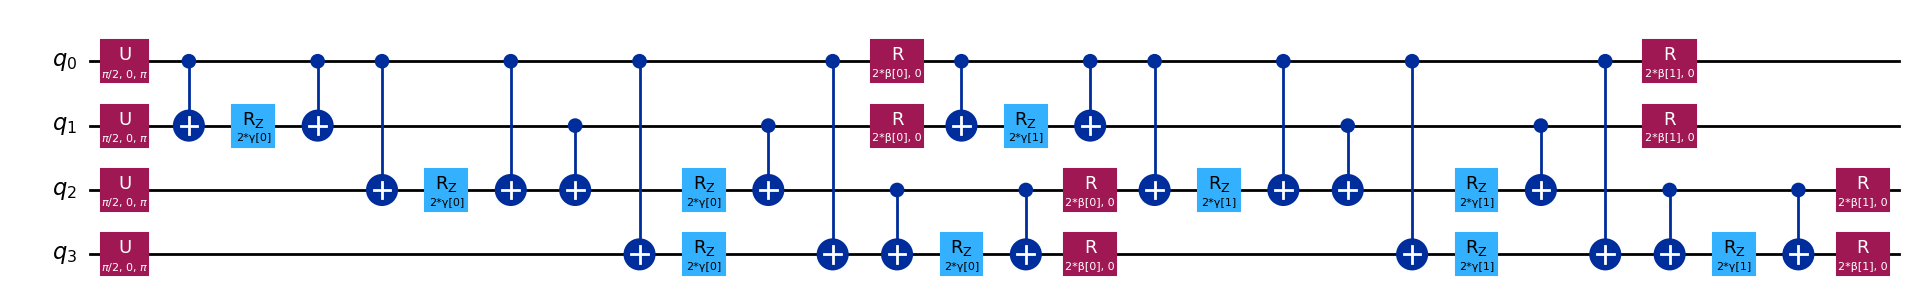

In [ ]:
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp

max_ham = SparsePauliOp.from_list(
    [("IIZZ", 1), ("IZIZ", 1), ("ZIIZ", 1),("IZZI", 1), ("ZZII", 1)]
)

max_ansatz = QAOAAnsatz(max_ham, reps=2)
max_ansatz.decompose(reps=3).draw("mpl", fold=-1)

In [5]:
offset = -sum(edge[2] for edge in edges) / 2
print(f"Offset: {offset}")

Offset: -2.5


In [6]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (Estimator): Estimator primitive instance

    Returns:
        float: Energy estimate
    """
    
    pub = (ansatz, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs
    
    return cost

#### Step 3 - Delcare the primitives and the params

In [7]:
from qiskit.primitives import StatevectorEstimator as sv_estimator, StatevectorSampler as sv_sampler
import numpy as np

sv_estimator = sv_estimator()
sv_sampler = sv_sampler()

params = 2 * np.pi * np.random.rand(max_ansatz.num_parameters)
print(params)

[4.05508517 5.47991617 3.79658529 0.76681798]


#### Step 4 - Minimze the cost function using classical optimizer

In [8]:
from scipy.optimize import minimize
result = minimize(cost_func, params, args=(max_ansatz, max_ham, sv_estimator), method='COBYLA')
print(result)

c:\Users\uthupku\OneDrive - Tecnotree\Personal_TT\Learning\Quant\Qiskit\QAMP\codebase\.qcenv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\uthupku\OneDrive - Tecnotree\Personal_TT\Learning\Quant\Qiskit\QAMP\codebase\.qcenv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
c:\Users\uthupku\OneDrive - Tecnotree\Personal_TT\Learning\Quant\Qiskit\QAMP\codebase\.qcenv\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -2.416721392837765
       x: [ 5.225e+00  5.616e+00  3.782e+00  1.849e+00]
    nfev: 58
   maxcv: 0.0


In [9]:
eigenvalue = cost_func(result.x, max_ansatz, max_ham, sv_estimator)
print(f"""Eigenvalue: {eigenvalue}""")
print(f"""Max-Cut Objective: {eigenvalue + offset}""")

Eigenvalue: -2.416721392837765
Max-Cut Objective: -4.916721392837765


#### Step 5 - Get the eigenstate using the optimal parameters for the minimized eigenvalue

In [10]:
from qiskit.result import QuasiDistribution

qc = max_ansatz.assign_parameters(result.x)
qc.measure_all()

shots = 4096
job = sv_sampler.run([qc], shots = shots)

data_pub = job.result()[0].data
bitstrings = data_pub.meas.get_bitstrings()
counts = data_pub.meas.get_counts()

quasi_dist = QuasiDistribution({outcome: freq / shots for outcome, freq in counts.items()})

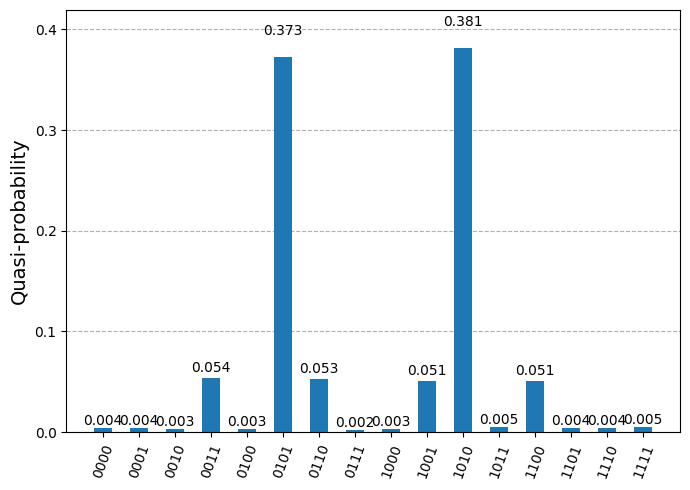

In [11]:
from qiskit.visualization import plot_distribution

plot_distribution(counts)

#### Step 6 - Visualize the cut on the graph

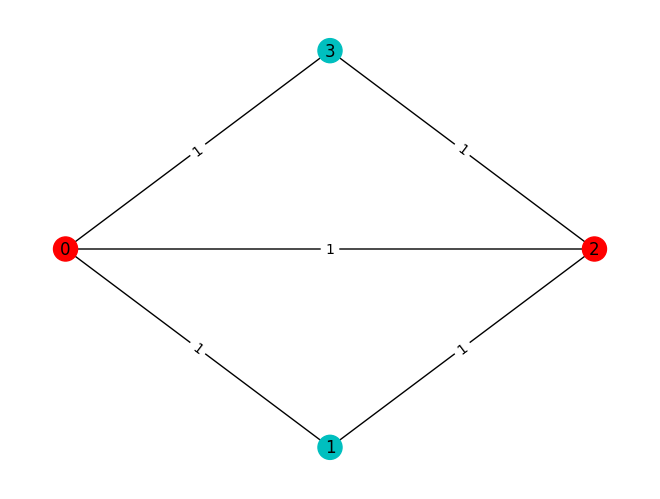

In [12]:
binary_string = max(counts.items(), key=lambda kv: kv[1])[0]
x = np.asarray([int(y) for y in reversed(list(binary_string))])

colors = ["r" if x[i] == 0 else "c" for i in range(nodes)]
mpl_draw(
    G, pos=rx.shell_layout(G), with_labels=True, edge_labels=str, node_color=colors
)